Monte Carlo Option Pricing

Creates a brownian motion and uses ito lemma 

In [9]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

prices = yf.download("SPY", start="2015-01-01", auto_adjust=False)["Close"]

S0 = float(prices.iloc[-1])
R = 0.04
sigma = 0.05
T = 365 / 252
nPaths = 100000 

dt = 1.0/252
        
        # Vectorised implementation of asset path generation
        # including four prices per day, used to create OHLC
assetPath = S0 * np.exp(
    np.cumsum((R - 0.5 * sigma**2) * dt +
        sigma * np.sqrt(dt) * np.random.randn(252)))

Z = np.random.randn(nPaths)
        # Apply GBM closed form solution
ST = S0 * np.exp((R - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

print("Asset Path:", assetPath)
print("ST:", ST)

[*********************100%***********************]  1 of 1 completed

Asset Path: [660.16626533 659.8329582  660.1013261  661.90204302 663.19456583
 660.32491611 660.42361536 661.0554584  662.89784715 664.95060903
 663.7687355  666.57450435 670.05050951 670.29398824 669.09199933
 669.93198677 670.7034338  669.04280987 670.27929929 672.27371185
 674.81858185 673.17861246 675.94101956 678.02496735 679.03131399
 680.06189579 677.94477836 675.18862788 675.6821112  675.0374426
 674.72026602 674.80264129 673.07248648 675.07979546 672.77915975
 672.77938437 668.72475236 674.75298291 675.98242451 681.12591685
 682.77550489 682.91367183 686.28140074 684.82647208 680.36127829
 681.7312542  681.64335479 680.96984275 680.78168529 681.12456549
 678.97574446 676.82656152 675.39714492 676.0245337  676.08132814
 678.9656446  679.66042776 681.10573852 678.79965143 679.19745253
 681.7016172  678.06016414 675.39570522 675.575993   678.08698225
 677.50431047 679.19319099 680.42997112 683.32207056 684.64412771
 684.47504573 681.31551777 681.64821804 674.43613361 676.05023078


C:\Users\matth\AppData\Local\Temp\ipykernel_13608\2106912651.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(prices.iloc[-1])


Calculates the Discounted Values from using the Max Call value and the Max put Value

In [8]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

prices = yf.download("SPY", start="2015-01-01", auto_adjust=False)["Close"]

S0 = float(prices.iloc[-1])
R = 0.04
sigma = 0.05
K = 2500
T = 365 / 252
nPaths = 100000 

Z = np.random.randn(nPaths)
        # Apply GBM closed form solution
ST = S0 * np.exp((R - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

maxCallVal = np.maximum(ST - K, 0)
    
maxPutVal = np.maximum(K - ST, 0)
    
discountCall = np.exp(-R * T) * np.mean(maxCallVal)
discountPut = np.exp(-R * T) * np.mean(maxPutVal)

print("Initial Price:", S0)

print("Mean Terminal Price:", np.mean(ST))
print("Standard deviation Terminal Price:", np.std(ST))

print("Call:", maxCallVal)
print("Put:", maxPutVal)

print("maxDiscountCall:", discountCall)
print("maxDiscountPut:", discountPut)

[*********************100%***********************]  1 of 1 completed

Initial Price: 661.8200073242188
Mean Terminal Price: 701.299048269498
Standard deviation Terminal Price: 42.28831062566059
Call: [0. 0. 0. ... 0. 0. 0.]
Put: [1752.27195484 1799.9101229  1803.65232274 ... 1892.55991347 1763.57003405
 1793.48715615]
maxDiscountCall: 0.0
maxDiscountPut: 1697.451829853016



C:\Users\matth\AppData\Local\Temp\ipykernel_13608\1440818415.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(prices.iloc[-1])


[*********************100%***********************]  1 of 1 completed
C:\Users\matth\AppData\Local\Temp\ipykernel_13608\1602849490.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(prices.iloc[-1])


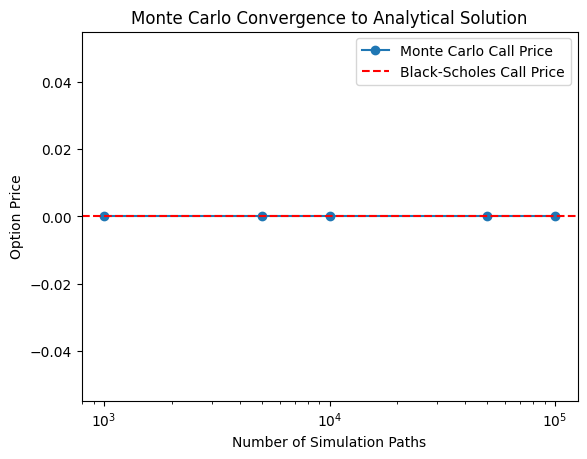

In [7]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

prices = yf.download("SPY", start="2015-01-01", auto_adjust=False)["Close"]

S0 = float(prices.iloc[-1])
R = 0.04
sigma = 0.05
K = 2500
T = 365 / 252

def black_scholes_call(S0, K, T, r, sigma):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

# Monte Carlo convergence
n_paths_list = [1000, 5000, 10000, 50000, 100000]
mc_prices = []

for n_paths in n_paths_list:
    Z = np.random.randn(n_paths)
    ST = S0 * np.exp((R - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    call_price = np.exp(-R*T) * np.mean(np.maximum(ST - K, 0))
    mc_prices.append(call_price)

bs_price = black_scholes_call(S0, K, T, R, sigma)

# Plot convergence
import matplotlib.pyplot as plt
plt.plot(n_paths_list, mc_prices, marker='o', label="Monte Carlo Call Price")
plt.axhline(bs_price, color='red', linestyle='--', label="Black-Scholes Call Price")
plt.xscale('log')
plt.xlabel("Number of Simulation Paths")
plt.ylabel("Option Price")
plt.title("Monte Carlo Convergence to Analytical Solution")
plt.legend()
plt.show()

Graph for the Geometric Brownian Motion Paths

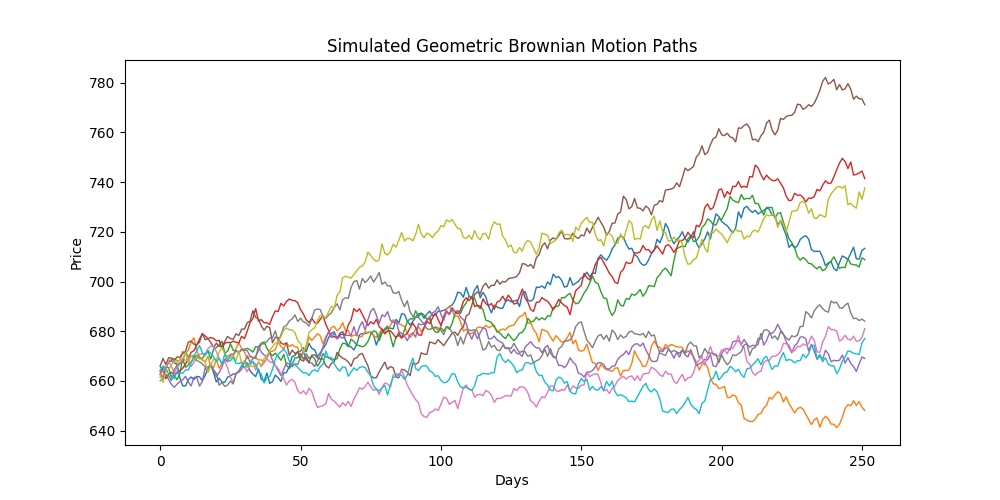

In [6]:
from IPython.display import Image

Image("SimulatedGeometricBrownianMotionPaths.png")

Graph for the distribution of terminal prices using Monte Carlo

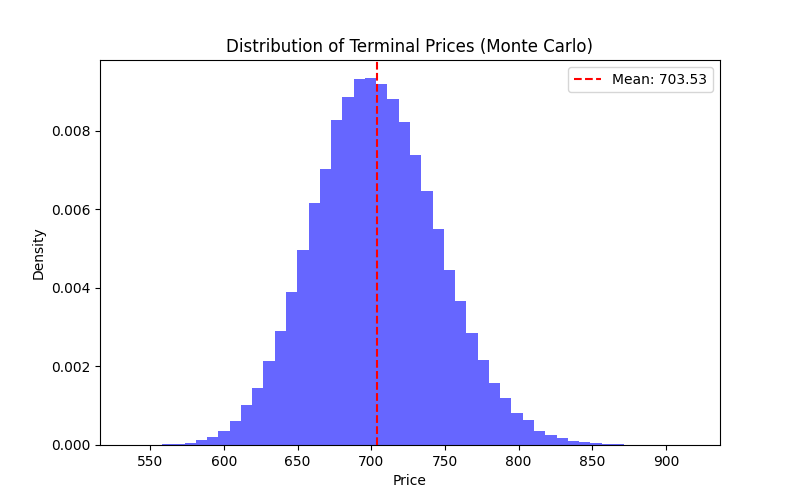

In [5]:
from IPython.display import Image

Image("MonteCarloGraph.png")

[*********************100%***********************]  1 of 1 completed
C:\Users\matth\AppData\Local\Temp\ipykernel_13608\4217382459.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(prices.iloc[-1])


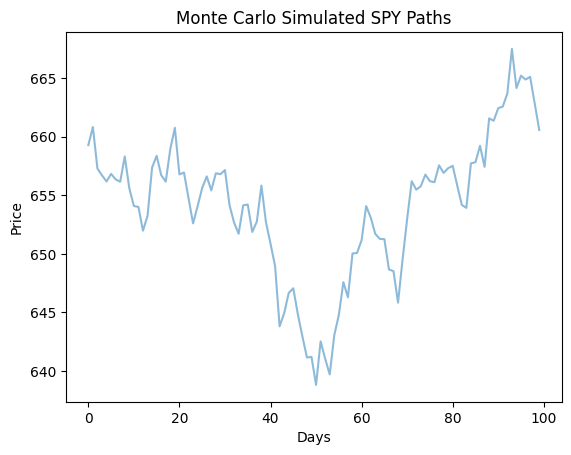

In [4]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

prices = yf.download("SPY", start="2015-01-01", auto_adjust=False)["Close"]

S0 = float(prices.iloc[-1])
R = 0.04
sigma = 0.05
T = 365 / 252
nPaths = 100000 

dt = 1.0/252
        
        # Vectorised implementation of asset path 
        
assetPath = S0 * np.exp(
    np.cumsum((R - 0.5 * sigma**2) * dt +
        sigma * np.sqrt(dt) * np.random.randn(252)))

plt.plot(assetPath[:100].T, alpha=0.5)
plt.title("Monte Carlo Simulated SPY Paths")
plt.xlabel("Days")
plt.ylabel("Price")
plt.show()